# Week 3 — threshold optimisation (Wednesday, 1 hour)

Six exercises on the studio's **sweep**. Everything calls **fc-10's own** `sweep` and Decision Log. The rule, the population
and the numbers are the ones the studio draws. Every rate is against **PLANTED TRUTH**.

Run with `FC10_REPOSITORY` set (see `training/README.md`). Read `README.md` in this folder first.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_curve

sys.path.insert(0, str(Path.cwd().parents[1]))
from tools.tm_sim_source import load, fc10_module

tm_sim, metrics = load()
sweep = fc10_module("runtime.manufacturing.tuning.sweep")
decision_log = fc10_module("runtime.manufacturing.tuning.decision_log")

pop = tm_sim.generate()
result = sweep.run(pop, "high_value")
curve = pd.DataFrame(result["points"])
TODAY = result["rule"]["current_threshold"]
print(result["label_source"], "·", result["note"])
print(f"{len(curve)} thresholds, £{curve.threshold.min():,.0f}–£{curve.threshold.max():,.0f}; today £{TODAY:,.0f}")

PLANTED_TRUTH · Rates are against planted truth in a synthetic population, not SAR outcomes.
77 thresholds, £10,000–£200,000; today £75,000


## Exercise 1 — the curve

Precision, recall and F1 against the threshold, with today's line marked. This is the chart the studio draws at `GET /`.

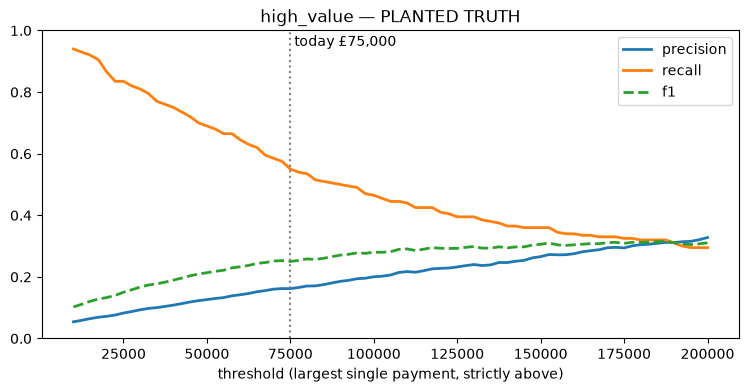

In [2]:
fig, ax = plt.subplots(figsize=(9, 4))
for col, style in (("precision", "-"), ("recall", "-"), ("f1", "--")):
    ax.plot(curve.threshold, curve[col], style, lw=2, label=col)
ax.axvline(TODAY, c="grey", ls=":"); ax.text(TODAY, 0.95, f" today £{TODAY:,.0f}")
ax.set_xlabel("threshold (largest single payment, strictly above)"); ax.set_ylim(0, 1); ax.legend()
ax.set_title("high_value — PLANTED TRUTH"); plt.show()

## Exercise 2 — the same curve, from sklearn

Treat each customer's largest payment as a **score**. sklearn's `precision_recall_curve` then gives the same trade-off,
parameterised by score instead of by our grid. One subtlety: sklearn alerts on `score >= t` while the rule fires on `>`.
The amounts are floats, so the two only differ where a payment lands exactly on the line.

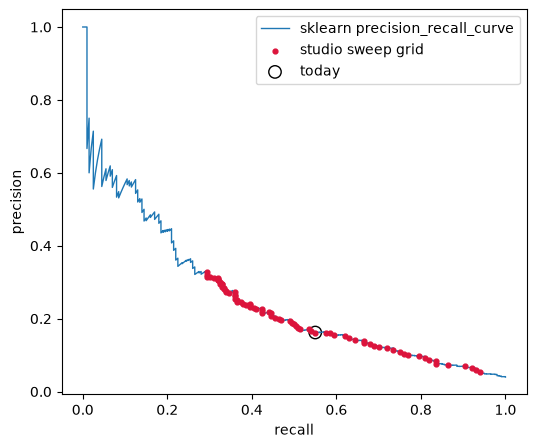

In [3]:
labels, top = pop.labels(), pop.max_amount_by_customer()
ids = sorted(labels)
y = np.array([labels[i] for i in ids]); score = np.array([top[i] for i in ids])
P, R, T = precision_recall_curve(y, score)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(R, P, lw=1, label="sklearn precision_recall_curve")
ax.scatter(curve.recall, curve.precision, s=12, c="crimson", label="studio sweep grid", zorder=3)
today = curve[curve.threshold == TODAY].iloc[0]
ax.scatter([today.recall], [today.precision], s=80, facecolors="none", edgecolors="k", label="today")
ax.set_xlabel("recall"); ax.set_ylabel("precision"); ax.legend(); plt.show()

## Exercise 3 — sensitivity around today

How much recall, and how many alerts, does each £10k move buy or cost around £75k? Measure the slope before arguing the point.

In [4]:
near = curve[(curve.threshold >= TODAY - 25_000) & (curve.threshold <= TODAY + 25_000)].set_index("threshold")
per_10k = near[["alerts", "recall", "precision"]].diff().div(near.index.to_series().diff() / 10_000, axis=0)
pd.concat({"value": near[["alerts", "recall", "precision"]], "change per £10k": per_10k}, axis=1).round(3)

value                  change per £10k                 
          alerts recall precision          alerts recall precision
threshold                                                         
50000       1092  0.690     0.126             NaN    NaN       NaN
52500       1047  0.680     0.130          -180.0  -0.04     0.014
55000       1001  0.665     0.133          -184.0  -0.06     0.012
57500        960  0.665     0.139          -164.0   0.00     0.023
60000        908  0.645     0.142          -208.0  -0.08     0.014
62500        862  0.630     0.146          -184.0  -0.06     0.016
65000        817  0.620     0.152          -180.0  -0.04     0.022
67500        765  0.595     0.156          -208.0  -0.10     0.015
70000        730  0.585     0.160          -140.0  -0.04     0.019
72500        710  0.575     0.162           -80.0  -0.04     0.007
75000        679  0.550     0.162          -124.0  -0.10     0.000
77500        652  0.540     0.166          -108.0  -0.04     0.015
80000        628  0.535     0.170           -96.0  -0.02     0.019
82500        603  0.515     0.171          -100.0  -0.08     0.002
85000        583  0.510     0.175           -80.0  -0.02     0.017
87500        560  0.505     0.180           -92.0  -0.02     0.022
90000        539  0.500     0.186           -84.0  -0.02     0.021
92500        524  0.495     0.189           -60.0  -0.02     0.014
95000        505  0.490     0.194           -76.0  -0.02     0.021
97500        480  0.470     0.196          -100.0  -0.08     0.007
100000       464  0.465     0.200           -64.0  -0.02     0.018

## Exercise 4 — max-F1 is a landmark, not a decision

Find the F1 maximum and set it beside today. What does it give up?

In [5]:
best = curve.loc[curve.f1.idxmax()]
pd.DataFrame({"today": today, "max F1": best}).loc[["threshold", "alerts", "tp", "fn", "precision", "recall", "f1"]]

,today,max F1
threshold,75000,187500
alerts,679,205
tp,110,64
fn,90,136
precision,0.162003,0.312195
recall,0.55,0.32
f1,0.250284,0.316049


## Exercise 5 — cost-weighted optimisation, and a dominated threshold

State *k*: one missed case costs as much as *k* false alerts. For each *k* from 1 to 100 the studio finds the cheapest
threshold, and the result is a staircase. Look for £75,000 on it.

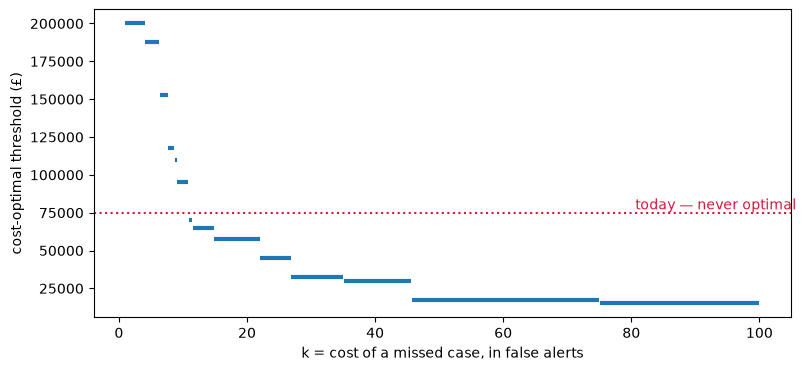

today optimal for any k in 1..100: False


,threshold,fn_fp_from,fn_fp_to
0,200000,1.0,4.0
1,187500,4.1,6.3
2,152500,6.4,7.6
3,117500,7.7,8.6
4,110000,8.7,9.0
5,95000,9.1,10.8
6,70000,10.9,11.4
7,65000,11.5,14.8
8,57500,14.9,22.0
9,45000,22.1,26.8


In [6]:
ranges = pd.DataFrame(sweep.cost_optimal_ranges(result))
fig, ax = plt.subplots(figsize=(9, 4))
for r in ranges.itertuples():
    ax.hlines(r.threshold, r.fn_fp_from, r.fn_fp_to, lw=3)
ax.axhline(TODAY, c="crimson", ls=":"); ax.text(80, TODAY, " today — never optimal", color="crimson", va="bottom")
ax.set_xlabel("k = cost of a missed case, in false alerts"); ax.set_ylabel("cost-optimal threshold (£)")
plt.show()
print("today optimal for any k in 1..100:", TODAY in set(ranges.threshold))
ranges

This is the evidence **Decision 1** was taken on. The entry below is read straight from fc-10's log; its figures were
computed, not typed, and fc-10 recomputes them on every test run.

In [7]:
[d1] = [e for e in decision_log.load() if e["decision_id"] == "D1"]
print(d1["decision"], "at", f"£{d1['to_threshold']:,.0f}", "—", d1["date"])
print("\n", d1["rationale"]); print("\nrevisit:", d1["revisit"])

HOLD at £75,000 — 2026-09-24

 On the TM-SIM planted-truth population GBP 75,000 is dominated: it is not the cost-optimal threshold for any FN:FP ratio from 1 to 100, and the best F1 on the whole curve is 0.316 at GBP 187,500, catching under a third of planted cases. So a flat amount threshold is not the lever. Held rather than moved because any move is a call on what a missed case is worth, which nobody has stated, made on a population whose truth we planted -- tuning a live threshold to it would be fitting our own assumptions.

revisit: Decision 2 (week 4) sets the operating point under an investigator capacity limit; Decision 4 (week 6) tests a relative, customer-baseline rule as the challenger, which is what the value_spike blind spot actually needs.


## Exercise 6 — turn the scenario down: the stress test

Planted truth has a dial. `intensity` scales the planted spike; 1.0 is the designed scenario. Weaken it and see how the
curve collapses and where the optimum moves. That shows the rule's blind spot, and it shows that the "best"
threshold depends on how we planted the behaviour.

In [8]:
rows = []
for intensity in (1.0, 0.75, 0.5, 0.25):
    r = sweep.run(tm_sim.generate(intensity=intensity), "high_value")
    at_today = next(p for p in r["points"] if p["threshold"] == TODAY)
    best20 = sweep.cost_weighted_best(r, fn_cost=20, fp_cost=1)["point"]
    rows.append({"intensity": intensity, "recall @ £75k": at_today["recall"],
                 "precision @ £75k": at_today["precision"],
                 "optimum @ k=20": best20["threshold"], "recall there": best20["recall"]})
pd.DataFrame(rows).set_index("intensity")

,recall @ £75k,precision @ £75k,optimum @ k=20,recall there
intensity,,,,
1.00,0.55,0.162003,57500,0.665
0.75,0.47,0.141780,45000,0.660
0.50,0.37,0.115086,30000,0.675
0.25,0.24,0.077796,45000,0.385


## Your answers (the curriculum's success criteria)

1. **Which threshold would you recommend, and on what stated assumption about *k*?** Use Exercise 5.

    *…*

2. **Why is max-F1 not your answer?** Use Exercise 4.

    *…*

3. **How sensitive is recall to the threshold around £75k, and does that argue for moving it or leaving it?** Use Exercise 3.

    *…*

4. **What does Exercise 6 say about moving a live threshold on planted truth?**

    *…*